In [1]:
print('Running imports...')
import os
from captum.attr import IntegratedGradients, NoiseTunnel

os.environ["MKL_THREADING_LAYER"] = "GNU"

import torch # long
from lightning.pytorch import seed_everything
import xarray as xr
from tqdm import tqdm
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import argparse

import sys 
import seaborn as sns
sys.path.append('/home/rogui7909/code/predict_rain_norway/predict_rain')

from ml_module_rain.models.trained_models import load_trained_model
from ml_module_rain.models.neuralnetworks import CNN_MLP#get_neural_network, ConvLayerStride1MaxPool,ConvLayerStride1_ConvLayerStride2, ConvLayerStride2NoMaxPool, ConvLayerStride2NoMaxPool_dropout


from ml_module_rain.data.datamodule import MyDataLoader

Running imports...


In [2]:
print('Running imports...')
import os
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"

import wandb
import torch # long
from lightning.pytorch import loggers, seed_everything
import xarray as xr
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
import argparse


from ml_module_rain.models.neuralnetworks import get_neural_network, register_shape_hooks
from ml_module_rain.data.datamodule import MyDataLoader
from ml_module_rain.models.lightning import ExtremeRainPredictor, AttributableTrainer
from ml_module_rain.models.losses import get_loss
from ml_module_rain.models.callbacks import LogF1Validation, get_checkpoint_callback
from ml_module_rain.utils.config import load_config
from pathlib import Path

Running imports...


In [3]:
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)
init_config = load_config('/home/rogui7909/code/predict_rain_norway/predict_rain/ml_module_rain/configs/config-defaults.yaml')
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_v6", 
                                save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb",
                                config=init_config )

wandb_logger.experiment # Initialize wandb
config = wandb_logger.experiment.config
dataloader = MyDataLoader(config)
dataloader.print_infos()

Seed set to 42
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Data ready:
    Image size: 16380 (182x90)
    Input variables: u850
    21732 samples in train
    4657 samples in validation
    4658 samples in test
    4 Predicted timesteps for future rainfall
    Prediction type: three_classes_grey_zone
    What quantile is considered extreme: 90th of rainy days


In [4]:
NN = CNN_MLP(feature_height=90, 
             feature_width=182,
             input_channels=1,
             output_neurons=12,
             CNN_number_of_layers=7,
             CNN_output_channels_first_layer=4,
             CNN_base_module = 'conv+pool',
             MLP_hidden_layers_neuron_number = [512,512], 
             dropout_MLP = 0.1,
             use_residuals=True,
             global_kwargs_encoder=dict(batch_norm= True, dropout=.1),
             kwargs_per_layer_encoder = [],)

In [5]:

callbacks=[EarlyStopping(monitor="val/loss", mode="min"), 
            get_checkpoint_callback(wandb_logger),
            LogF1Validation(num_timesteps=config['num_timesteps_predicted']),
            ]
trainer = AttributableTrainer(limit_train_batches=100, 
                            max_epochs=config['num_epochs'], 
                            logger=wandb_logger, 
                            log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                            callbacks=callbacks, deterministic=True,
                            accelerator="cpu", devices=1)

loss = get_loss(config['loss_function'], timesteps = config['num_timesteps_predicted'])
lightroom_model = ExtremeRainPredictor(NN, 
                        learning_rate=config['learning_rate'], 
                        lr_scheduler =config['lr_scheduler'],
                        loss_fn = loss,
                        init_config=init_config)
trainer.fit(lightroom_model,dataloader.train_loader, dataloader.val_loader)
lightroom_model.eval()
lightroom_model.model.eval()
with torch.no_grad():
    trainer.test(lightroom_model, dataloaders=dataloader.val_loader)


wandb.finish()



GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:658: Checkpoint directory /felles_gfi/felles_gfi_users/rogui7909/data/NN_outputs/checkpoints exists and is not empty.

  | Name    | Type                  | Params | Mode 
----------------------------------------------------------
0 | model   | CNN_MLP               | 970 K  | train
1 | loss_fn | MultiCrossEntropyLoss | 0      | train
----------------------------------------------------------
970 K     Trainable params
0         Non-trainable params
970 K     Total params
3.881     Total estimated model params size (MB)
95        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.5354029536247253     │
└───────────────────────────┴───────────────────────────┘

epoch,▁▁▁▁▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇████
test/loss,▁
train/loss,█▄▄▄▄▃▃▃▃▃▂▂▂▂▂▃▃▂▂▂▂▂▃▂▁▂▂▁▁▁▂▁▁▂▁▁▁▁▂▂
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇████
val/f1_epoch,▂▁▆▇▇▇▇▇▇███████████████
val/loss,█▅▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val/precision_epoch,▁█▄▄▅▄▄▅▄▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅
val/recall_epoch,▄▁▅▆▆▇▇▇▇▇▇█████████████
epoch,23
test/loss,0.5354
train/loss,0.46716


In [6]:
run_id = 'rijrwij6'
samples_to_attribute='TP'


all_targets = []
all_probas = []
for batch in tqdm(dataloader.val_loader):
    x, y = batch
    lightroom_model.eval()
    with torch.no_grad():
        all_probas.append(lightroom_model(x))
    all_targets.append(y)
probas = torch.cat(all_probas).view(-1, 4, 3)
targets = torch.cat(all_targets).cpu().numpy()
preds = torch.argmax(probas, dim=2).cpu().numpy() 
probas = probas.cpu().numpy()

ds_aligned = dataloader.ds_val.isel(time=range(targets.shape[0]))
preds_da = xr.DataArray(preds, dims=['time','timestep'], coords =ds_aligned.targets.coords)
ds_aligned ['predictions'] = preds_da


series_targets = ds_aligned.targets.to_series()
series_predictions = ds_aligned.predictions.to_series()

all_predictions = pd.DataFrame(dict(predictions=series_predictions, targets=series_targets)).reset_index()
all_predictions.columns = ['time_of_prediction','timestep','prediction','target']
all_predictions['time_of_event'] = all_predictions.time_of_prediction + all_predictions.timestep*pd.Timedelta(1,'D')
valid_times = all_predictions.groupby("time_of_event").target.count().reset_index().query("target==4").time_of_event # Only four predictions
all_predictions = all_predictions.loc[all_predictions.time_of_event.isin(valid_times)]

match samples_to_attribute:
    case 'TP':
        time_of_attributions = all_predictions.query("(prediction==target) & (target==2)").groupby('time_of_event').time_of_prediction.count().reset_index().query("time_of_prediction==4").time_of_event.values
    case 'all-extr':
        time_of_attributions =all_predictions.query("prediction==2 | target==2").time_of_event.unique()
    case 'all':
        time_of_attributions = all_predictions.time_of_event.unique()
    case _:
        print("Invalid selection of attributions")

predictions_attributions = all_predictions.loc[all_predictions.time_of_event.isin(time_of_attributions)].sort_values(['time_of_event','timestep'], ascending=[True, False])
start_times = predictions_attributions.query("timestep==3").time_of_prediction.dt.strftime("%Y-%m-%d %H:%M:%S").values
end_times = predictions_attributions.query("timestep==0").time_of_prediction.dt.strftime("%Y-%m-%d %H:%M:%S").values

method = IntegratedGradients(lightroom_model.model)
all_multi_attrs = []
all_multi_sens = []
steps=4

for k in tqdm(range(len(start_times))):
    start = start_times[k]
    end = end_times[k]
    # print(start,end)
    ds_test_extract =  ds_aligned.sel(time=slice(start ,end))
    tensor_in = torch.Tensor(ds_test_extract.features.values)
    tensor_out = torch.Tensor(ds_test_extract.targets.values)
    attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
    da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
                            coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
    all_multi_attrs.append(da_attrs.assign_coords(time=time_of_attributions[k]))
    sens = da_attrs/ds_test_extract.features.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)
    all_multi_sens.append(sens.assign_coords(time=time_of_attributions[k]))
    # break
ds_attributions = xr.concat(all_multi_attrs, dim='time').assign_coords(timestep=np.arange(-3,1))
ds_sens = xr.concat(all_multi_sens, dim='time').assign_coords(timestep=np.arange(-3,1))
ds_predictions_attributions = predictions_attributions.set_index(['time_of_event','timestep'])[['prediction','target']].to_xarray().rename(time_of_event='time')
ds_predictions_attributions = ds_predictions_attributions.assign_coords(timestep=-ds_predictions_attributions.timestep).sortby('timestep')
final_ds = xr.merge([xr.Dataset(dict(attributions = ds_attributions, sensitivity=ds_sens)), ds_predictions_attributions])
final_ds.to_netcdf(f"/Data/gfi/users/rogui7909/data/NN_outputs/attributions/{run_id}_attributions_{samples_to_attribute}.nc")


100%|██████████| 100/100 [00:13<00:00,  7.30it/s]


In [55]:
encoder = Encoder(1, 7,
        use_residuals=True,
        output_channels_first_layer=8,
        channels_increase_per_layer=2,
        downsample_mode="doubleconv", # Can be a list
        global_kwargs=dict(),
        kwargs_per_layer = [dict(batch_norm = True, dropout = 0),
                            dict(batch_norm = True, dropout = 0),
                            dict(batch_norm = True, dropout = 0),
                            dict(batch_norm = True, dropout = 0.3),
                            dict(batch_norm = True, dropout = 0.3),
                            dict(batch_norm = True, dropout = 0.3),
                            dict(batch_norm = True, dropout = 0.3)])
mlp = MLP(1024, 12, dropout=.4)


test = torch.zeros(1,1,90,181)
test = encoder(test).view(-1, 1024)
test = mlp(test)
test.shape
# encoder

torch.Size([1, 12])

In [ ]:
all_features = xr.open_dataset("/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr")


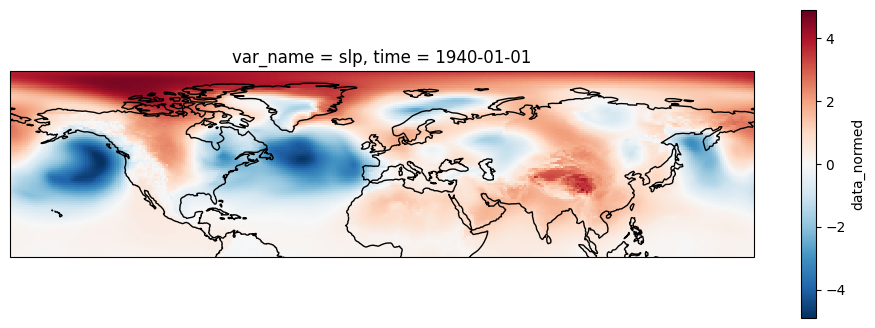

In [ ]:
X = all_features.isel(time=0, var_name=0).data_normed
import cartopy.crs as ccrs
plot = X.plot(subplot_kws=dict(projection=ccrs.PlateCarree()), transform=ccrs.PlateCarree(), size=4, aspect=3)
plot.axes.coastlines()

In [ ]:
# from torch import nn
# import torch.nn.functional as F
# class ResidualBlock(nn.Module):
#     def __init__(self, base_module, input_channels, output_channels, **base_module_kwargs):
#         super(ResidualBlock, self).__init__()
#         self.main = base_module(input_channels, output_channels, **base_module_kwargs)

#         self.skip_connection = nn.Identity()
#         if input_channels != output_channels:
#             self.skip_connection = nn.Conv2d(input_channels, output_channels, kernel_size=1, stride=1)
        
#         self.pool_match = False
#         self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
#         self.activation = nn.ReLU()

#     def forward(self, x):
#         identity = self.skip_connection(x)
#         if identity.shape[-2] % 2 != 0 or identity.shape[-1] % 2 != 0:
#             identity = F.pad(identity, (0, identity.shape[-1] % 2, 0, identity.shape[-2] % 2))
#         identity = self.pool(identity)
#         out = self.main(x)
#         out = self.activation(out + identity)
#         return out

In [8]:
conv = ResidualBlock(ConvolutionBlock, 1, 1, 
                     downsample_mode="convstride", 
                     batch_norm=True, 
                     dropout=0.3)


test = torch.zeros(1,1,90,360)
conv(conv(conv(conv(conv(conv((conv(test))))))))

tensor([[[[1.3997, 0.8491, 1.3822]]]], grad_fn=<ReluBackward0>)

In [15]:
a =dict(a =2)
not a

False

In [85]:
# test.shape
for mode in ["conv+pool", "stride", "double"]:
    block = get_downsample_block(mode, in_channels=1, out_channels=16)
    out = block(test)
    print(f"{mode:10s}: {out.shape}")

conv+pool : torch.Size([1, 16, 5, 32])
stride    : torch.Size([1, 16, 5, 32])
double    : torch.Size([1, 16, 5, 32])


In [58]:
from torch import nn
class ConvLayerStride1MaxPool(nn.Module):
    def __init__(self, 
                 input_channels, 
                 output_channels,
                 activation_function='ReLU',
                 size_conv_kernel=3,
                 ):
        super(ConvLayerStride1MaxPool, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        match activation_function:
            case 'ReLU':
                self.activation_function = nn.ReLU()
        self.conv_layer = nn.Conv2d(self.input_channels, 
                                    self.output_channels, 
                                    kernel_size=size_conv_kernel, 
                                    stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(output_channels)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        output = self.conv_layer(x)
        output = self.bn2(output)
        output = self.maxpool(output)
        output = self.activation_function(output)
        return output


In [ ]:

class ConvLayerStride2NoMaxPool(nn.Module):
    def __init__(self, 
                 input_channels, 
                 output_channels,
                 activation_function='ReLU',
                 size_conv_kernel=3
                 ):
        super(ConvLayerStride2NoMaxPool, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        match activation_function:
            case 'ReLU':
                self.activation_function = nn.ReLU()
        self.conv_layer = nn.Conv2d(self.input_channels, 
                                    self.output_channels, 
                                    kernel_size=size_conv_kernel, 
                                    stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(output_channels)
        
    def forward(self, x):
        output = self.conv_layer(x)
        # output = self.bn2(output)
        output = self.activation_function(output)
        return output

class ConvLayerStride1MaxPool(nn.Module):
    def __init__(self, 
                 input_channels, 
                 output_channels,
                 activation_function='ReLU',
                 size_conv_kernel=3,
                 ):
        super(ConvLayerStride1MaxPool, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        match activation_function:
            case 'ReLU':
                self.activation_function = nn.ReLU()
        self.conv_layer = nn.Conv2d(self.input_channels, 
                                    self.output_channels, 
                                    kernel_size=size_conv_kernel, 
                                    stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(output_channels)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2,ceil_mode=True)

    def forward(self, x):
        output = self.conv_layer(x)
        output = self.bn2(output)
        output = self.maxpool(output)
        output = self.activation_function(output)
        return output
    
                 
class ConvLayerStride1_ConvLayerStride2(nn.Module):
    def __init__(self, 
                 input_channels, 
                 output_channels,
                 activation_function='ReLU',
                 size_conv_kernel=3
                 ):
        super(ConvLayerStride1_ConvLayerStride2, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        match activation_function:
            case 'ReLU':
                self.activation_function = nn.ReLU()
        self.conv_layer1 = nn.Conv2d(self.input_channels, 
                                    self.output_channels, 
                                    kernel_size=size_conv_kernel, 
                                    stride=1, padding=(size_conv_kernel-1)//2)
        self.conv_layer2 = nn.Conv2d(self.output_channels, 
                                    self.output_channels, 
                                    kernel_size=2, 
                                    stride=2, padding=0)
        
        self.bn2 = nn.BatchNorm2d(output_channels)

    def forward(self, x):
        output = self.conv_layer1(x)
        output = self.conv_layer2(output)
        output = self.bn2(output)
        output = self.activation_function(output)
        return output

In [79]:

conv1 = ConvLayerStride1MaxPool(1,16)
conv2 = ConvLayerStride1_ConvLayerStride2(1,16)
conv3 = ConvLayerStride2NoMaxPool(1,16)

for k1 in range (10,100):
    for k2 in range(k1, 200):
        test = torch.zeros(1,1,k1,k2)
        maxpool = conv1(test).shape
        nomaxpool = conv3(test).shape
        doubleconv = conv2(test).shape
        if not (maxpool == nomaxpool == doubleconv):
            print('Test shape: ',test.shape)
            print('  maxpool',maxpool)
            print('  nomaxpool',nomaxpool)
            print('  doubleconv',doubleconv)

Test shape:  torch.Size([1, 1, 10, 11])
  maxpool torch.Size([1, 16, 5, 6])
  nomaxpool torch.Size([1, 16, 5, 6])
  doubleconv torch.Size([1, 16, 5, 5])
Test shape:  torch.Size([1, 1, 10, 13])
  maxpool torch.Size([1, 16, 5, 7])
  nomaxpool torch.Size([1, 16, 5, 7])
  doubleconv torch.Size([1, 16, 5, 6])
Test shape:  torch.Size([1, 1, 10, 15])
  maxpool torch.Size([1, 16, 5, 8])
  nomaxpool torch.Size([1, 16, 5, 8])
  doubleconv torch.Size([1, 16, 5, 7])
Test shape:  torch.Size([1, 1, 10, 17])
  maxpool torch.Size([1, 16, 5, 9])
  nomaxpool torch.Size([1, 16, 5, 9])
  doubleconv torch.Size([1, 16, 5, 8])
Test shape:  torch.Size([1, 1, 10, 19])
  maxpool torch.Size([1, 16, 5, 10])
  nomaxpool torch.Size([1, 16, 5, 10])
  doubleconv torch.Size([1, 16, 5, 9])
Test shape:  torch.Size([1, 1, 10, 21])
  maxpool torch.Size([1, 16, 5, 11])
  nomaxpool torch.Size([1, 16, 5, 11])
  doubleconv torch.Size([1, 16, 5, 10])
Test shape:  torch.Size([1, 1, 10, 23])
  maxpool torch.Size([1, 16, 5, 12])


KeyboardInterrupt: 

In [7]:
from ml_module_rain.utils.config import load_config

config = load_config('/home/rogui7909/code/predict_rain_norway/predict_rain/ml_module_rain/configs/config-defaults.yaml')
dataloader = MyDataLoader(config)

In [33]:
from torch import nn
class ResidualBlock(nn.Module):
    def __init__(self, base_module, input_channels, output_channels):
        super(ResidualBlock, self).__init__()
        self.main = base_module(input_channels, output_channels)

        self.skip_connection = nn.Identity()
        if input_channels != output_channels:
            self.skip_connection = nn.Conv2d(input_channels, output_channels, kernel_size=1, stride=1)
        
        self.pool_match = False
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2, padding=0)
        self.activation = nn.ReLU()

    def forward(self, x):
        identity = self.skip_connection(x)
        identity = self.pool(identity)
        out = self.main(x)
        out = self.activation(out + identity)
        return out

In [40]:
ConvLayerStride2NoMaxPool_dropout

ml_module_rain.models.neuralnetworks.ConvLayerStride2NoMaxPool_dropout

In [42]:
conv = ConvLayerStride1MaxPool_dropout(1,16)
test = torch.zeros(1,1,90,182)

ResidualBlock(ConvLayerStride2NoMaxPool_dropout, 1, 16)(test)

TypeError: '<' not supported between instances of 'tuple' and 'int'

In [8]:
NN = get_neural_network(config)

RuntimeError: The size of tensor a (92) must match the size of tensor b (91) at non-singleton dimension 3

In [2]:
run_id = 'dfkp0m9h'
samples_to_attribute = 'TP'
dataloader, lightning_model = load_trained_model(run_id)
lightning_model.eval()
lightning_model.model.eval()
all_targets = []
all_probas = []
for batch in tqdm(dataloader.val_loader):
    x, y = batch
    lightning_model.eval()
    with torch.no_grad():
        all_probas.append(lightning_model(x))
    all_targets.append(y)
probas = torch.cat(all_probas).view(-1, 4, 3)
targets = torch.cat(all_targets).cpu().numpy()
preds = torch.argmax(probas, dim=2).cpu().numpy() 
probas = probas.cpu().numpy()

ds_aligned = dataloader.ds_val.isel(time=range(targets.shape[0]))
preds_da = xr.DataArray(preds, dims=['time','timestep'], coords =ds_aligned.targets.coords)
# probas_da = xr.DataArray(probas, dims=['time','timestep'], coords =ds_aligned.targets.coords)
ds_aligned ['predictions'] = preds_da


Data ready:
    Image size: 16380 (182x90)
    Input variables: u850
    21732 samples in train
    4657 samples in validation
    4658 samples in test
    4 Predicted timesteps for future rainfall
    Prediction type: three_classes_grey_zone
    What quantile is considered extreme: 90th of rainy days


100%|██████████| 9/9 [00:11<00:00,  1.26s/it]


In [ ]:
df_ = ds_aligned[['rain','targets','predictions']].to_dataframe().iloc[:,:-1]
df_['TP'] = df_.targets.isin([1,2]) & df_.predictions.isin([1,2])
# df_['FP'] = df_.targets.isin([0]) & (df_.predictions.isin([2]))
# recall = df_['TP'].sum()/(df_['TP'].sum()+df_['FP'].sum())
# recall

In [11]:
df_.reset_index().groupby(['targets','predictions']).timestep.count().unstack()

predictions,0,2
targets,,
0,14366,2026
1,345,375
2,375,945


In [51]:
probas_da = xr.DataArray(probas, dims=['time','timestep','class_n'], coords =ds_aligned.targets.coords)
ds_aligned ['predictions'] = preds_da

In [56]:
probas_da.sel(time=all_predictions.query("timestep==3 & prediction==2 & target==2").time_of_prediction.values).isel(class_n=2, timestep=0).to_series().sort_values()

time
2008-01-22   -2.807960
2011-11-20   -2.486412
2007-10-25   -2.459958
2004-12-19   -2.282746
2003-12-15   -1.875774
                ...   
2006-12-11    4.724063
2005-01-07    4.790767
2008-01-25    4.889399
2000-01-08    4.927717
2011-11-26    5.230290
Length: 156, dtype: float32

In [ ]:

series_targets = ds_aligned.targets.to_series()
series_predictions = ds_aligned.predictions.to_series()

all_predictions = pd.DataFrame(dict(predictions=series_predictions, targets=series_targets)).reset_index()
all_predictions.columns = ['time_of_prediction','timestep','prediction','target']
all_predictions['time_of_event'] = all_predictions.time_of_prediction + all_predictions.timestep*pd.Timedelta(1,'D')
valid_times = all_predictions.groupby("time_of_event").target.count().reset_index().query("target==4").time_of_event # Only four predictions
all_predictions = all_predictions.loc[all_predictions.time_of_event.isin(valid_times)]

match samples_to_attribute:
    case 'TP':
        time_of_attributions = all_predictions.query("(prediction==target) & (target==2)").groupby('time_of_event').time_of_prediction.count().reset_index().query("time_of_prediction==4").time_of_event.values
    case 'all-extr':
        time_of_attributions =all_predictions.query("prediction==2 | target==2").time_of_event.unique()
    case 'all':
        time_of_attributions = all_predictions.time_of_event.unique()
    case _:
        print("Invalid selection of attributions")

predictions_attributions = all_predictions.loc[all_predictions.time_of_event.isin(time_of_attributions)].sort_values(['time_of_event','timestep'], ascending=[True, False])
start_times = predictions_attributions.query("timestep==3").time_of_prediction.dt.strftime("%Y-%m-%d %H:%M:%S").values
end_times = predictions_attributions.query("timestep==0").time_of_prediction.dt.strftime("%Y-%m-%d %H:%M:%S").values

all_multi_attrs = []
all_multi_sens = []
steps=4


In [88]:

net=lightning_model.model
lrp = LRP(net)
X = tensor_in.shape
# Attribution size matches input size: 3x3x32x32
attribution = lrp.attribute(X, target=5)

NameError: name 'LRP' is not defined

In [69]:
tensor_in.shape

torch.Size([1, 1, 90, 182])

In [ ]:
from captum.attr import IntegratedGradients
from captum.attr import Saliency
from captum.attr import DeepLift
from captum.attr import NoiseTunnel
from captum.attr import Occlusion

# method = IntegratedGradients(lightning_model.model)
method = Occlusion(lightning_model.model)

ds_test_extract = ds_aligned.sel(time=['2011-11-26'])
# print(start,end)
# ds_test_extract =  ds_aligned.sel(time=slice(start ,end))
tensor_in = torch.Tensor(ds_test_extract.features.values)
tensor_out = torch.Tensor(ds_test_extract.targets.values)
# attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
attrs = method.attribute(tensor_in,target=1, strides = (1, 4, 4), baselines=0, sliding_window_shapes=(1,8, 8)) 
da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
                        coords= dict(timestep=[0],var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
all_multi_attrs.append(da_attrs.assign_coords(time=time_of_attributions[k]))
sens = da_attrs/ds_test_extract.features.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)
all_multi_sens.append(sens.assign_coords(time=time_of_attributions[k]))

da_attrs.plot(col='timestep')
plt.figure()
ds_test_extract.isel(timestep=0).features.plot()

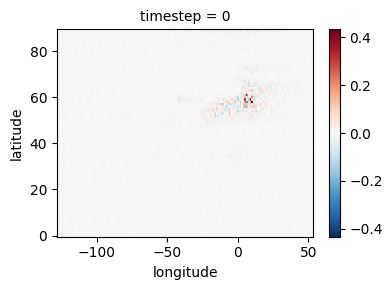

In [117]:
from captum.attr import IntegratedGradients
from captum.attr import Saliency
from captum.attr import DeepLift
from captum.attr import NoiseTunnel
from captum.attr import Occlusion
from captum.attr import LRP

# method = IntegratedGradients(lightning_model.model)
method = DeepLift(lightning_model.model)

ds_test_extract = ds_aligned.sel(time=['2011-11-26'])
# print(start,end)
# ds_test_extract =  ds_aligned.sel(time=slice(start ,end))
tensor_in = torch.Tensor(ds_test_extract.features.values)
tensor_out = torch.Tensor(ds_test_extract.targets.values)
# attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
with torch.no_grad():
    attrs = method.attribute(tensor_in,target=7) 
da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
                        coords= dict(timestep=[0],var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
sens = da_attrs/ds_test_extract.features.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)

da_attrs.plot(col='timestep')
# plt.figure()
# ds_test_extract.isel(timestep=0).features.plot()

In [94]:

layers = list(model._modules["features"]) + list(model._modules["classifier"])
num_layers = len(layers)

for idx_layer in range(1, num_layers):
    if idx_layer <= 16:
        setattr(layers[idx_layer], "rule", GammaRule())
    elif 17 <= idx_layer <= 30:
        setattr(layers[idx_layer], "rule", EpsilonRule())
    elif idx_layer >= 31:
        setattr(layers[idx_layer], "rule", EpsilonRule(epsilon=0))

lrp = LRP(model)
attributions_lrp = lrp.attribute(input, 
                                target=pred_label_idx)



KeyError: 'features'